In [1]:
import os
import glob
import json
import h5py
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as cl
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns
import pandas as pd
from collections import defaultdict
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    f1_score,
    cohen_kappa_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
)


In [2]:
def safe_cw_auc(targets, scores, mode = 'ovo', count_lim = 2):
    unique_targets, counts = np.unique(targets, return_counts=True)
    unique_targets = unique_targets[counts > count_lim]
    cw_auc = np.full(scores.shape[-1], np.nan)
    if len(unique_targets) == 1:
        return cw_auc
    for k in unique_targets:
        if mode == 'ovo':
            cw_auc[k] = 0
            for l in unique_targets:
                if l == k: continue
                tmp_mask = np.logical_or(targets == k, targets == l)
                tmp_targets = targets[tmp_mask]
                tmp_scores = scores[tmp_mask, k]
                cw_auc_kvl = roc_auc_score(tmp_targets == k,tmp_scores)
                cw_auc[k] += cw_auc_kvl/(len(unique_targets -1))
        elif mode == 'ovr':
            cw_auc[k] = roc_auc_score(targets == k, scores[:, k])
        else:
            raise "Mode must be ovo or ovr"
    return cw_auc

def safe_cw_pr_re_f1(targets, preds, num_classes, count_lim = 2):
    unique_targets, counts = np.unique(targets, return_counts=True)

    # Target count filter
    count_filt = np.full(num_classes, np.nan)
    count_filt[unique_targets[counts > count_lim]] = 1 

    # Calculate scores (results will only include present targets)
    cw_prec = precision_score(targets, preds, average=None, zero_division=np.nan)
    cw_rec = recall_score(targets, preds, average=None, zero_division=np.nan)
    cw_f1 = f1_score(targets, preds, average=None, zero_division=np.nan)

    # Initialize NaN arrays to fill to make sure all possible targets are representet
    cw_prec_array = np.full(num_classes, np.nan)
    cw_rec_array = np.full(num_classes, np.nan)
    cw_f1_array = np.full(num_classes, np.nan)

    # Fill in NaN arrays
    for i, k in enumerate(unique_targets):
        cw_prec_array[k] = cw_prec[i] * count_filt[i]
        cw_rec_array[k] = cw_rec[i] * count_filt[i]
        cw_f1_array[k] = cw_f1[i] * count_filt[i]

    return cw_prec_array, cw_rec_array, cw_f1_array

In [4]:
ss_labels_name = 'light_deep_rem'
ss_label_map = {
    'deep': 0,
    'light': 1,
    'rem': 2,
    'wake': 3,
    'missing': -9,
}
# ss_label_map_inv = {val: key for key, val in ss_label_map.items()}
ss_label_map_inv = {val: key for key, val in ss_label_map.items() if val != -9}
ss_label_order = ['wake', 'light', 'deep', 'rem']
ss_label_name = ['Wake', 'Light', 'Deep', 'REM']

ss_colormap = {
    'wake': 'tab:red',
    'light': 'tab:orange',
    'deep': 'tab:blue',
    'rem': 'tab:green',
}


In [28]:
## Subject-wise epoch by epoch classification metrics
cw_precs = defaultdict(list)
cw_recalls = defaultdict(list)
cw_f1s = defaultdict(list)

cw_aucs = defaultdict(list)
roc_curves = defaultdict(list)
soft_preds_all = []
targets_all = []

macro_results = defaultdict(list)
summary_diffs = defaultdict(list)
summary_means = defaultdict(list)
exp_i = []
subject_i = []
dataset_i = []
tp_i = []

# subject_i = []
# dataset_i = []
# tp_i = []
# experiment_dir = '/oak/stanford/groups/mignot/projects/actigraphy_fm/results/bwm_mae_tp/'
# for tp_dir in os.scandir(experiment_dir):
#     tp = float(tp_dir.path.split('_')[-1])
#     for dataset in os.scandir(tp_dir):
#         for sub_dir in os.scandir(dataset):
#             subject_i.append(os.path.basename(sub_dir))
#             dataset_i.append(os.path.basename(dataset))
#             tp_i.append(tp)

exp1_path = '/oak/stanford/groups/mignot/projects/actigraphy_fm/results/bwm_mae_tp/'
exp2_path = '/oak/stanford/groups/mignot/projects/actigraphy_fm/results/bwm_mae_lstmc_tp/'
experiments = [('Linear', exp1_path), ('LSTM-C', exp2_path)]
for exp_name, experiment_dir in experiments:
    for tp_dir in os.scandir(experiment_dir):
        tp = float(tp_dir.path.split('_')[-1])
        for dataset in os.scandir(tp_dir):
            for sub_dir in os.scandir(dataset):
                subject_i.append(os.path.basename(sub_dir))
                dataset_i.append(os.path.basename(dataset))
                exp_i.append(exp_name)
                tp_i.append(tp)

                missing_idx = ss_label_map['missing']

                scores = np.load(os.path.join(sub_dir.path + '/soft_preds.npy'))
                targets = np.load(os.path.join(sub_dir.path + '/targets.npy'))

                scores = scores[targets != missing_idx]
                targets = targets[targets != missing_idx]
                
                soft_preds_all.append(scores)
                targets_all.append(targets)
                
                # Get hard predictions
                preds = scores.argmax(axis=-1)

                unique_targets, counts = np.unique(targets, return_counts=True)
                unique_preds, pred_counts = np.unique(preds, return_counts=True)

                ## Subject-wise class-wise scores
                # Precision, Recall, and F1
                cw_pr, cw_re, cw_f1 = safe_cw_pr_re_f1(targets, preds, num_classes=scores.shape[-1], count_lim=3)
                
                # Manually compute binary AUC for each label present (NaN for non-valid)
                cw_auc = safe_cw_auc(targets, scores, mode='ovr', count_lim=3)

                for k in range(scores.shape[-1]):
                    cw_aucs[ss_label_map_inv[k]].append(float(cw_auc[k]))
                    cw_precs[ss_label_map_inv[k]].append(float(cw_pr[k]))
                    cw_recalls[ss_label_map_inv[k]].append(float(cw_re[k]))
                    cw_f1s[ss_label_map_inv[k]].append(float(cw_f1[k]))

                # Class-wise ROC curves
                for k in unique_targets:
                    roc = roc_curve(targets, scores[:,k], pos_label=k)
                    roc_curves[ss_label_map_inv[k]].append(roc)
                
                ## Subject-wise macro averages
                mac_prec = precision_score(targets, preds, average='macro', zero_division=np.nan)
                mac_rec = recall_score(targets, preds, average='macro', zero_division=np.nan)
                mac_f1 = f1_score(targets, preds, average='macro', zero_division=np.nan)
                kappa = cohen_kappa_score(targets, preds)
                macro_results['Precision'].append(mac_prec)
                macro_results['Recall'].append(mac_rec)
                macro_results['F1'].append(mac_f1)
                macro_results['Kappa'].append(kappa)
                macro_results['AUROC'].append(np.nanmean(cw_auc))

                
macro_results = pd.DataFrame(data=macro_results)
cw_aucs = pd.DataFrame(data=cw_aucs)
cw_precs = pd.DataFrame(data=cw_precs)
cw_recalls = pd.DataFrame(data=cw_recalls)
cw_f1s = pd.DataFrame(data=cw_f1s)

soft_preds_all = np.concatenate(soft_preds_all)
targets_all = np.concatenate(targets_all)
preds_all = soft_preds_all.argmax(axis=-1)

macro_results['subject'] = subject_i
macro_results['dataset'] = dataset_i
macro_results['classifier'] = exp_i
macro_results['tp'] = tp_i


In [31]:
macro_results['dataset'] = macro_results['dataset'].map({
    'newcastle_left': 'Newcastle L',
    'newcastle_right': 'Newcastle R',
    'stages': 'STAGES',
    'dreamt': 'DREAMT',
    'tbi': 'TBI',
})

In [32]:
macro_results_lin = macro_results.loc[macro_results['classifier'] == 'Linear']
macro_results_lstmc = macro_results.loc[macro_results['classifier'] == 'LSTM-C']


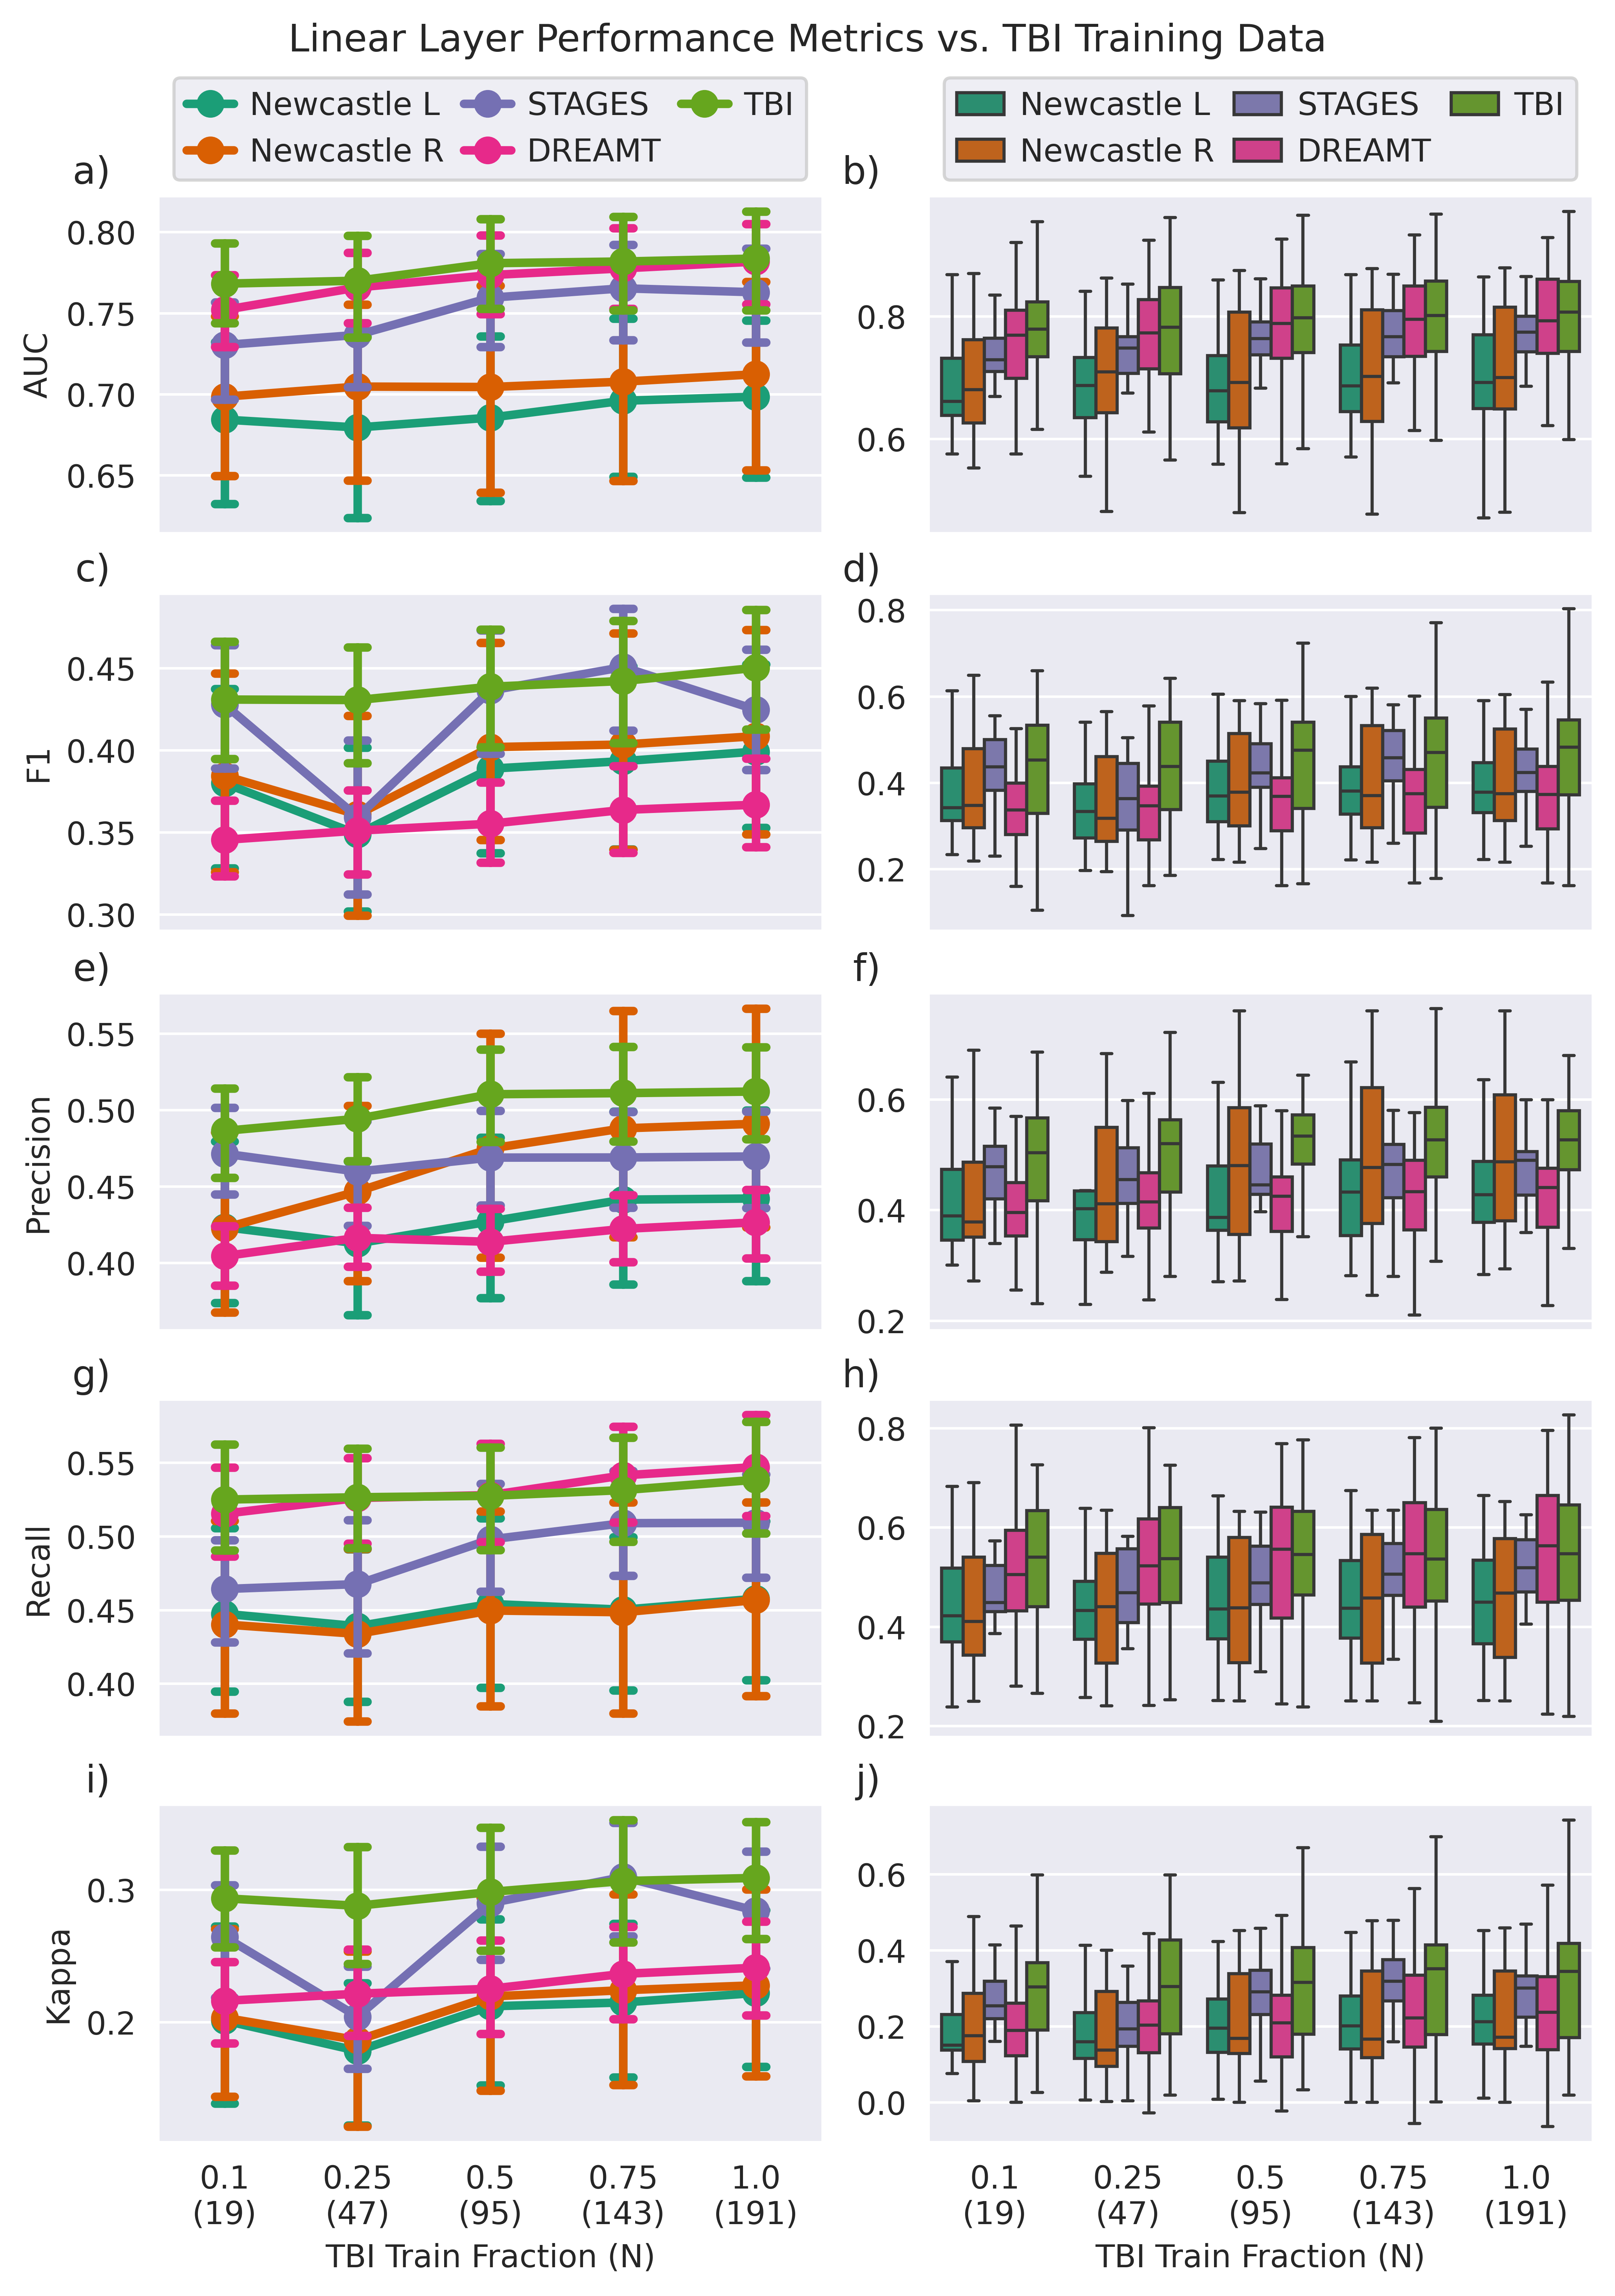

In [34]:
sns.set_style('darkgrid')
mvars = ['AUROC', 'F1', 'Precision', 'Recall', 'Kappa']

fig, axes = plt.subplots(len(mvars),2, dpi=600, figsize=(7,10),layout='constrained',sharex='col')
if len(axes.shape) == 1:
    axes = axes[None, :]
nsubs = [19, 47, 95, 143, 191]
fig.suptitle('Linear Layer Performance Metrics vs. TBI Training Data')
with sns.color_palette("Dark2"):
    for i, ax in enumerate(axes):
        sns.pointplot(
            macro_results_lin, x='tp', y=mvars[i], hue='dataset', ax=ax[0], legend=(i == 0), capsize=0.15,# errorbar=('ci', 95), err_style='bars', marker='o',
            hue_order=['Newcastle L', 'Newcastle R', 'STAGES', 'DREAMT', 'TBI']
        )
        sns.boxplot(
            macro_results_lin, x='tp', y=mvars[i], hue='dataset', saturation=0.75, ax=ax[1], legend=(i == 0), showfliers=False,
            hue_order=['Newcastle L', 'Newcastle R', 'STAGES', 'DREAMT', 'TBI']
        )
        if i == 0:
            ax[0].legend(bbox_to_anchor = (0,1,1,1), loc='lower left', ncols=3, 
                mode='expand', handletextpad=0.5, handlelength=1.5)
            ax[1].legend(bbox_to_anchor = (0,1,1,1), loc='lower left', ncols=3, 
                mode='expand', handletextpad=0.5, handlelength=1.5)

        ax[0].set_xlabel('')
        ax[0].set_ylabel(mvars[i])
        ax[1].set_xlabel('')
        ax[1].set_ylabel('')

        ax[0].set_xticks([0, 1, 2, 3, 4], ['0.1\n(19)', '0.25\n(47)', '0.5\n(95)', '0.75\n(143)', '1.0\n(191)'])
        ax[0].set_xlabel('TBI Train Fraction (N)')

        ax[1].set_xticks([0, 1, 2, 3, 4], ['0.1\n(19)', '0.25\n(47)', '0.5\n(95)', '0.75\n(143)', '1.0\n(191)'])
        ax[1].set_xlabel('TBI Train Fraction (N)')

    for i, ax in enumerate(axes.ravel()):
        # Add alphabetic ordering
        ax.annotate(
            f'{chr(97+i)})',
            xy=(-0.1, 1.07), xycoords='axes fraction',
            xytext=(+0.5, -0.5), textcoords='offset fontsize',
            fontsize='large', verticalalignment='bottom', horizontalalignment='right',# fontfamily='verdana',
            bbox=dict(facecolor='none', edgecolor='none', pad=3.0)
        )

    plt.show()

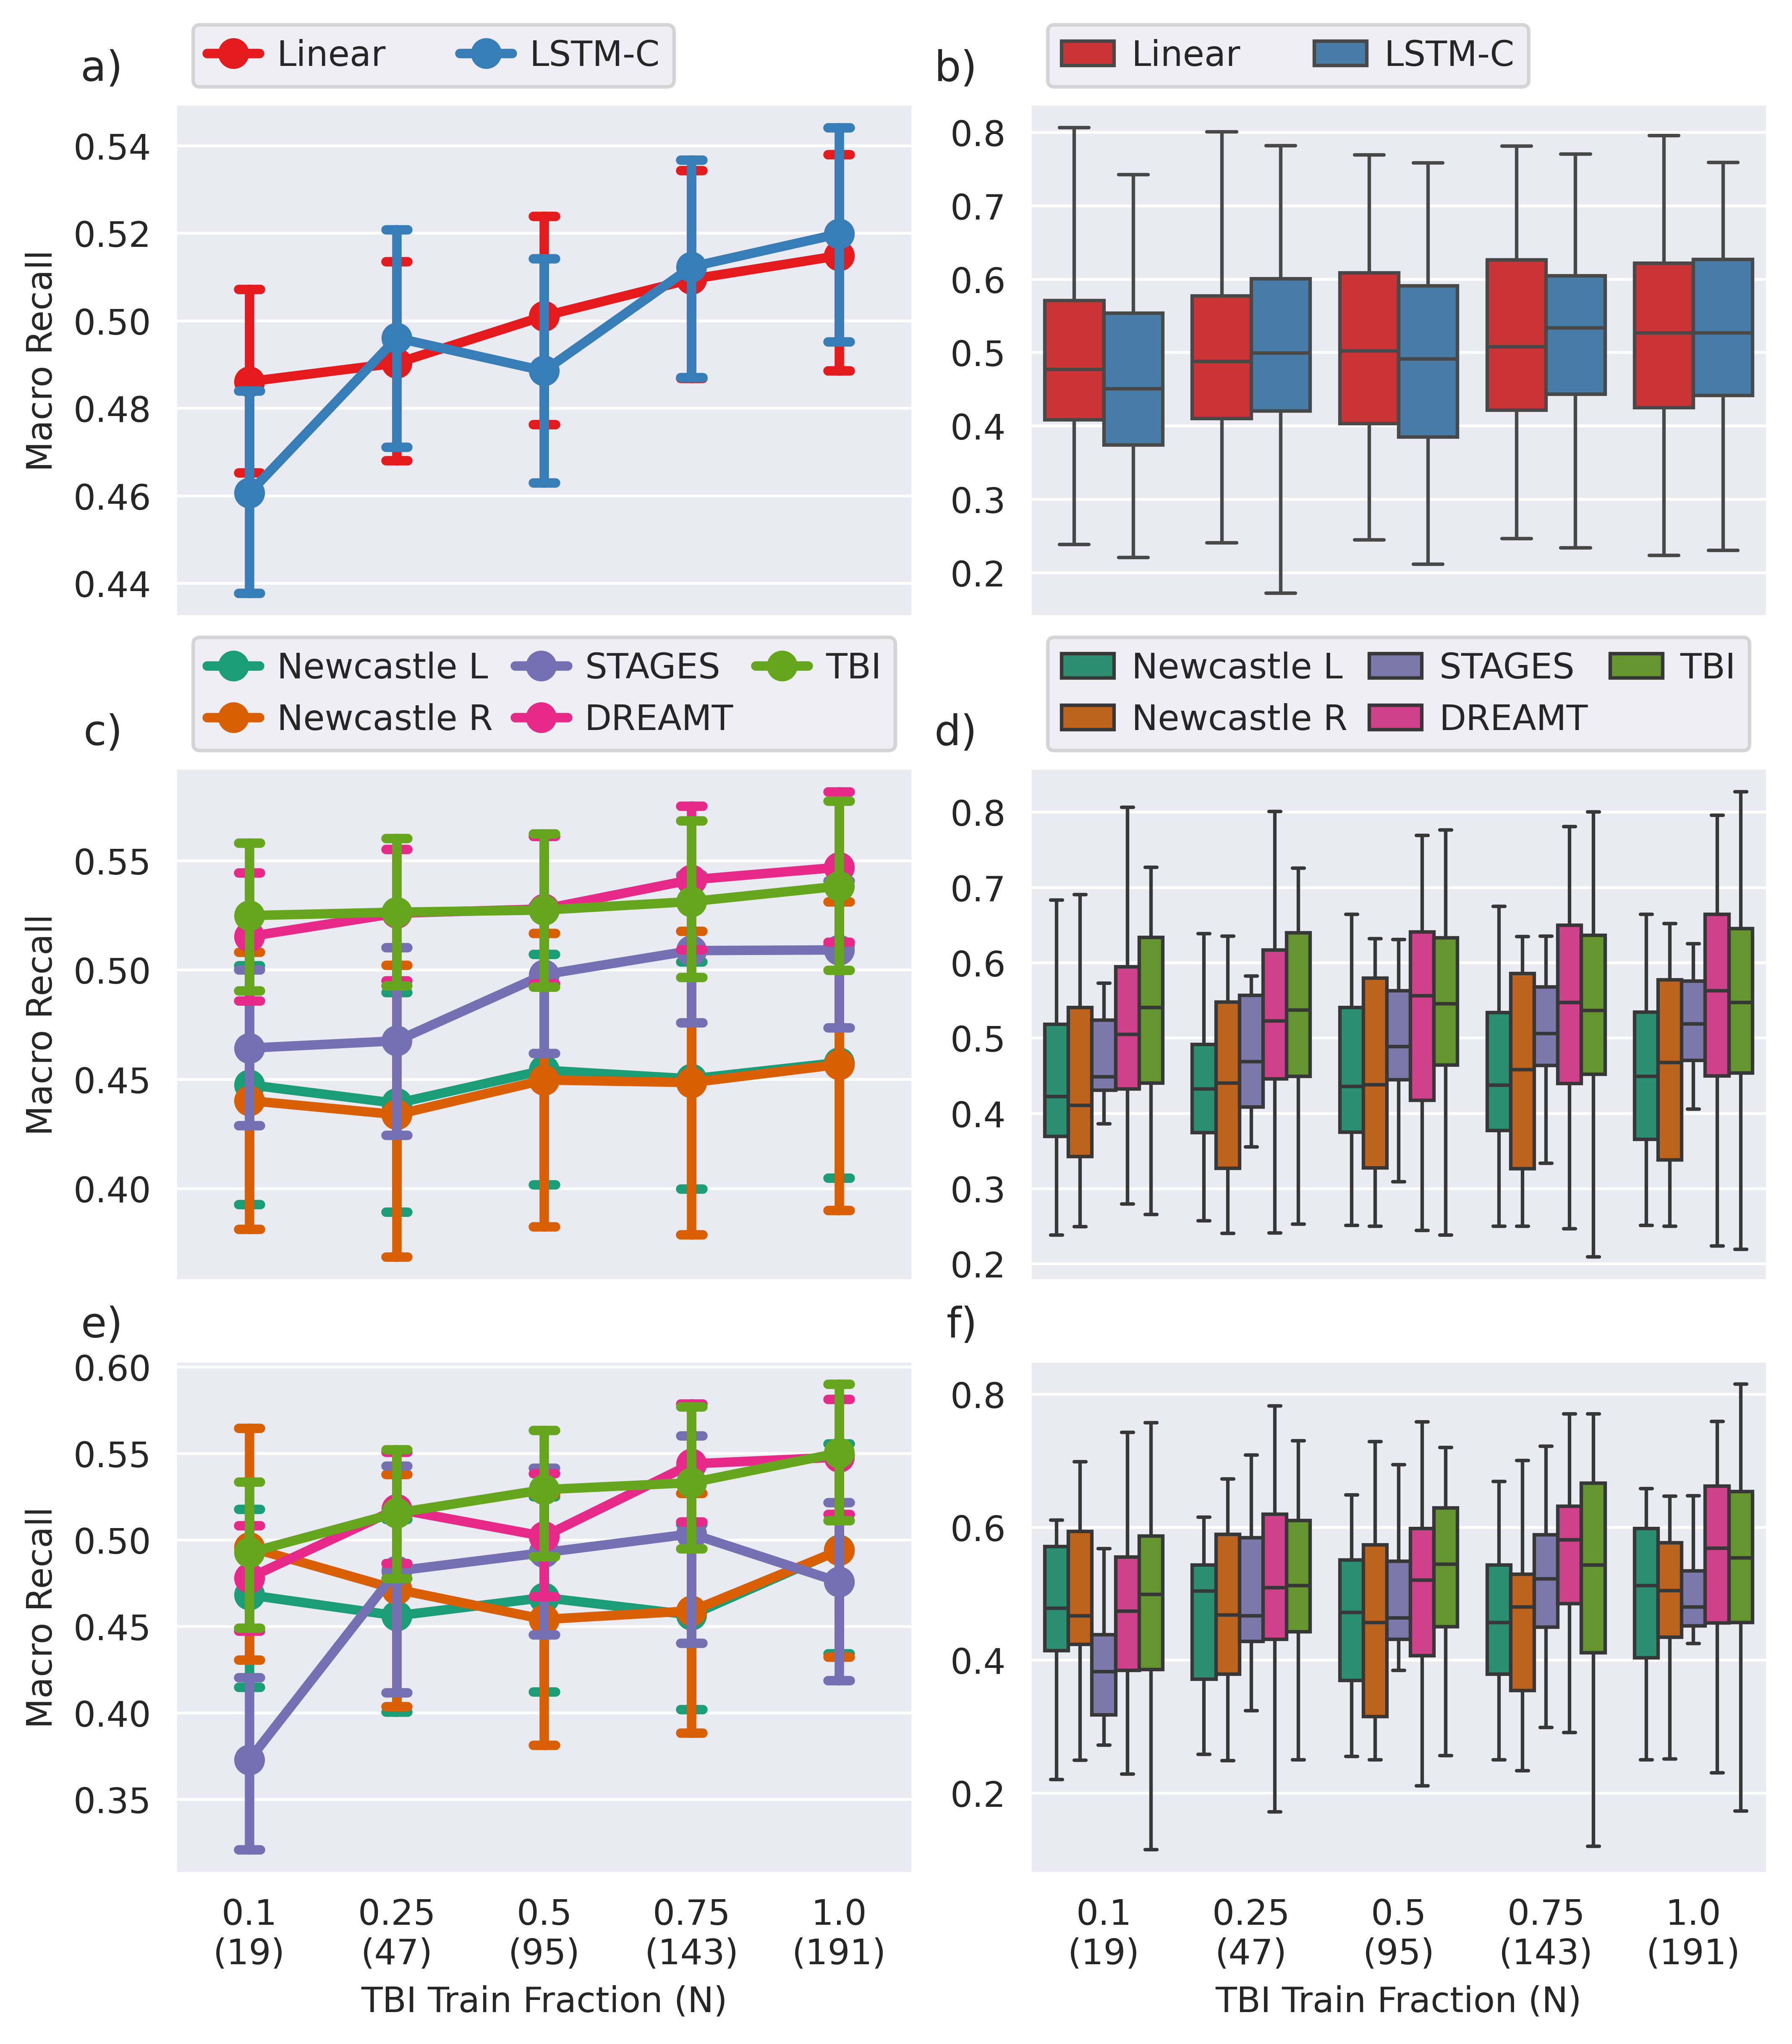

In [12]:
sns.set_style('darkgrid')
metric = 'Recall'#, 'Precision', 'Recall','F1', 'Kappa']
nsubs = [19, 47, 95, 143, 191]

fig, axes = plt.subplots(3,2, dpi=600, figsize=(7,8),layout='constrained',sharex='col')

ax0 = sns.pointplot(
    macro_results[macro_results['dataset'] != 'TBI'], x='tp', y=metric, hue='classifier', ax=axes[0,0], 
    capsize=0.15, palette='Set1'
)
ax1 = sns.boxplot(
    macro_results[macro_results['dataset'] != 'TBI'], x='tp', y=metric, hue='classifier', saturation=0.75, ax=axes[0,1], showfliers=False, palette='Set1'
)
ax0.set_ylabel(f'Macro {metric}')
ax1.set_ylabel('')
ax0.set_xticks([0, 1, 2, 3, 4], ['0.1\n(19)', '0.25\n(47)', '0.5\n(95)', '0.75\n(143)', '1.0\n(191)'])
ax0.set_xlabel('TBI Train Fraction (N)')

ax1.set_xticks([0, 1, 2, 3, 4], ['0.1\n(19)', '0.25\n(47)', '0.5\n(95)', '0.75\n(143)', '1.0\n(191)'])
ax1.set_xlabel('TBI Train Fraction (N)')

ax0.legend(bbox_to_anchor = (0,1,0.7,1), loc='lower left', ncols=3, 
    mode='expand', handletextpad=0.5, handlelength=1.5)
ax1.legend(bbox_to_anchor = (0,1,0.7,1), loc='lower left', ncols=3, 
    mode='expand', handletextpad=0.5, handlelength=1.5)


classifiers = [macro_results_lin, macro_results_lstmc]
for i, ax in enumerate(axes[1:]):
    sns.pointplot(
        classifiers[i], x='tp', y=metric, hue='dataset', ax=ax[0],
        legend=(i == 0), capsize=0.15, palette='Dark2',
        hue_order=['Newcastle L', 'Newcastle R', 'STAGES', 'DREAMT', 'TBI']
    )
    sns.boxplot(
        classifiers[i], x='tp', y=metric, hue='dataset', saturation=0.75, ax=ax[1], 
        legend=(i == 0), showfliers=False, palette='Dark2',
        hue_order=['Newcastle L', 'Newcastle R', 'STAGES', 'DREAMT', 'TBI']
    )
    if i == 0:
        ax[0].legend(bbox_to_anchor = (0,1,1,1), loc='lower left', ncols=3, 
            mode='expand', handletextpad=0.5, handlelength=1.5)
        ax[1].legend(bbox_to_anchor = (0,1,1,1), loc='lower left', ncols=3, 
            mode='expand', handletextpad=0.5, handlelength=1.5)

    ax[0].set_xlabel('')
    ax[0].set_ylabel(f'Macro {metric}')
    ax[1].set_xlabel('')
    ax[1].set_ylabel('')

    ax[0].set_xticks([0, 1, 2, 3, 4], ['0.1\n(19)', '0.25\n(47)', '0.5\n(95)', '0.75\n(143)', '1.0\n(191)'])
    ax[0].set_xlabel('TBI Train Fraction (N)')

    ax[1].set_xticks([0, 1, 2, 3, 4], ['0.1\n(19)', '0.25\n(47)', '0.5\n(95)', '0.75\n(143)', '1.0\n(191)'])
    ax[1].set_xlabel('TBI Train Fraction (N)')

for i, ax in enumerate(axes.ravel()):
    # Add alphabetic ordering
    ax.annotate(
        f'{chr(97+i)})',
        xy=(-0.1, 1.07), xycoords='axes fraction',
        xytext=(+0.5, -0.5), textcoords='offset fontsize',
        fontsize='large', verticalalignment='bottom', horizontalalignment='right',# fontfamily='verdana',
        bbox=dict(facecolor='none', edgecolor='none', pad=3.0)
    )

plt.show()

/tmp/ipykernel_6390/685667556.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(bbox_to_anchor = (0,1,0.7,1), loc='lower left', ncols=2,


ValueError: Could not interpret value `AUC` for `y`. An entry with this name does not appear in `data`.

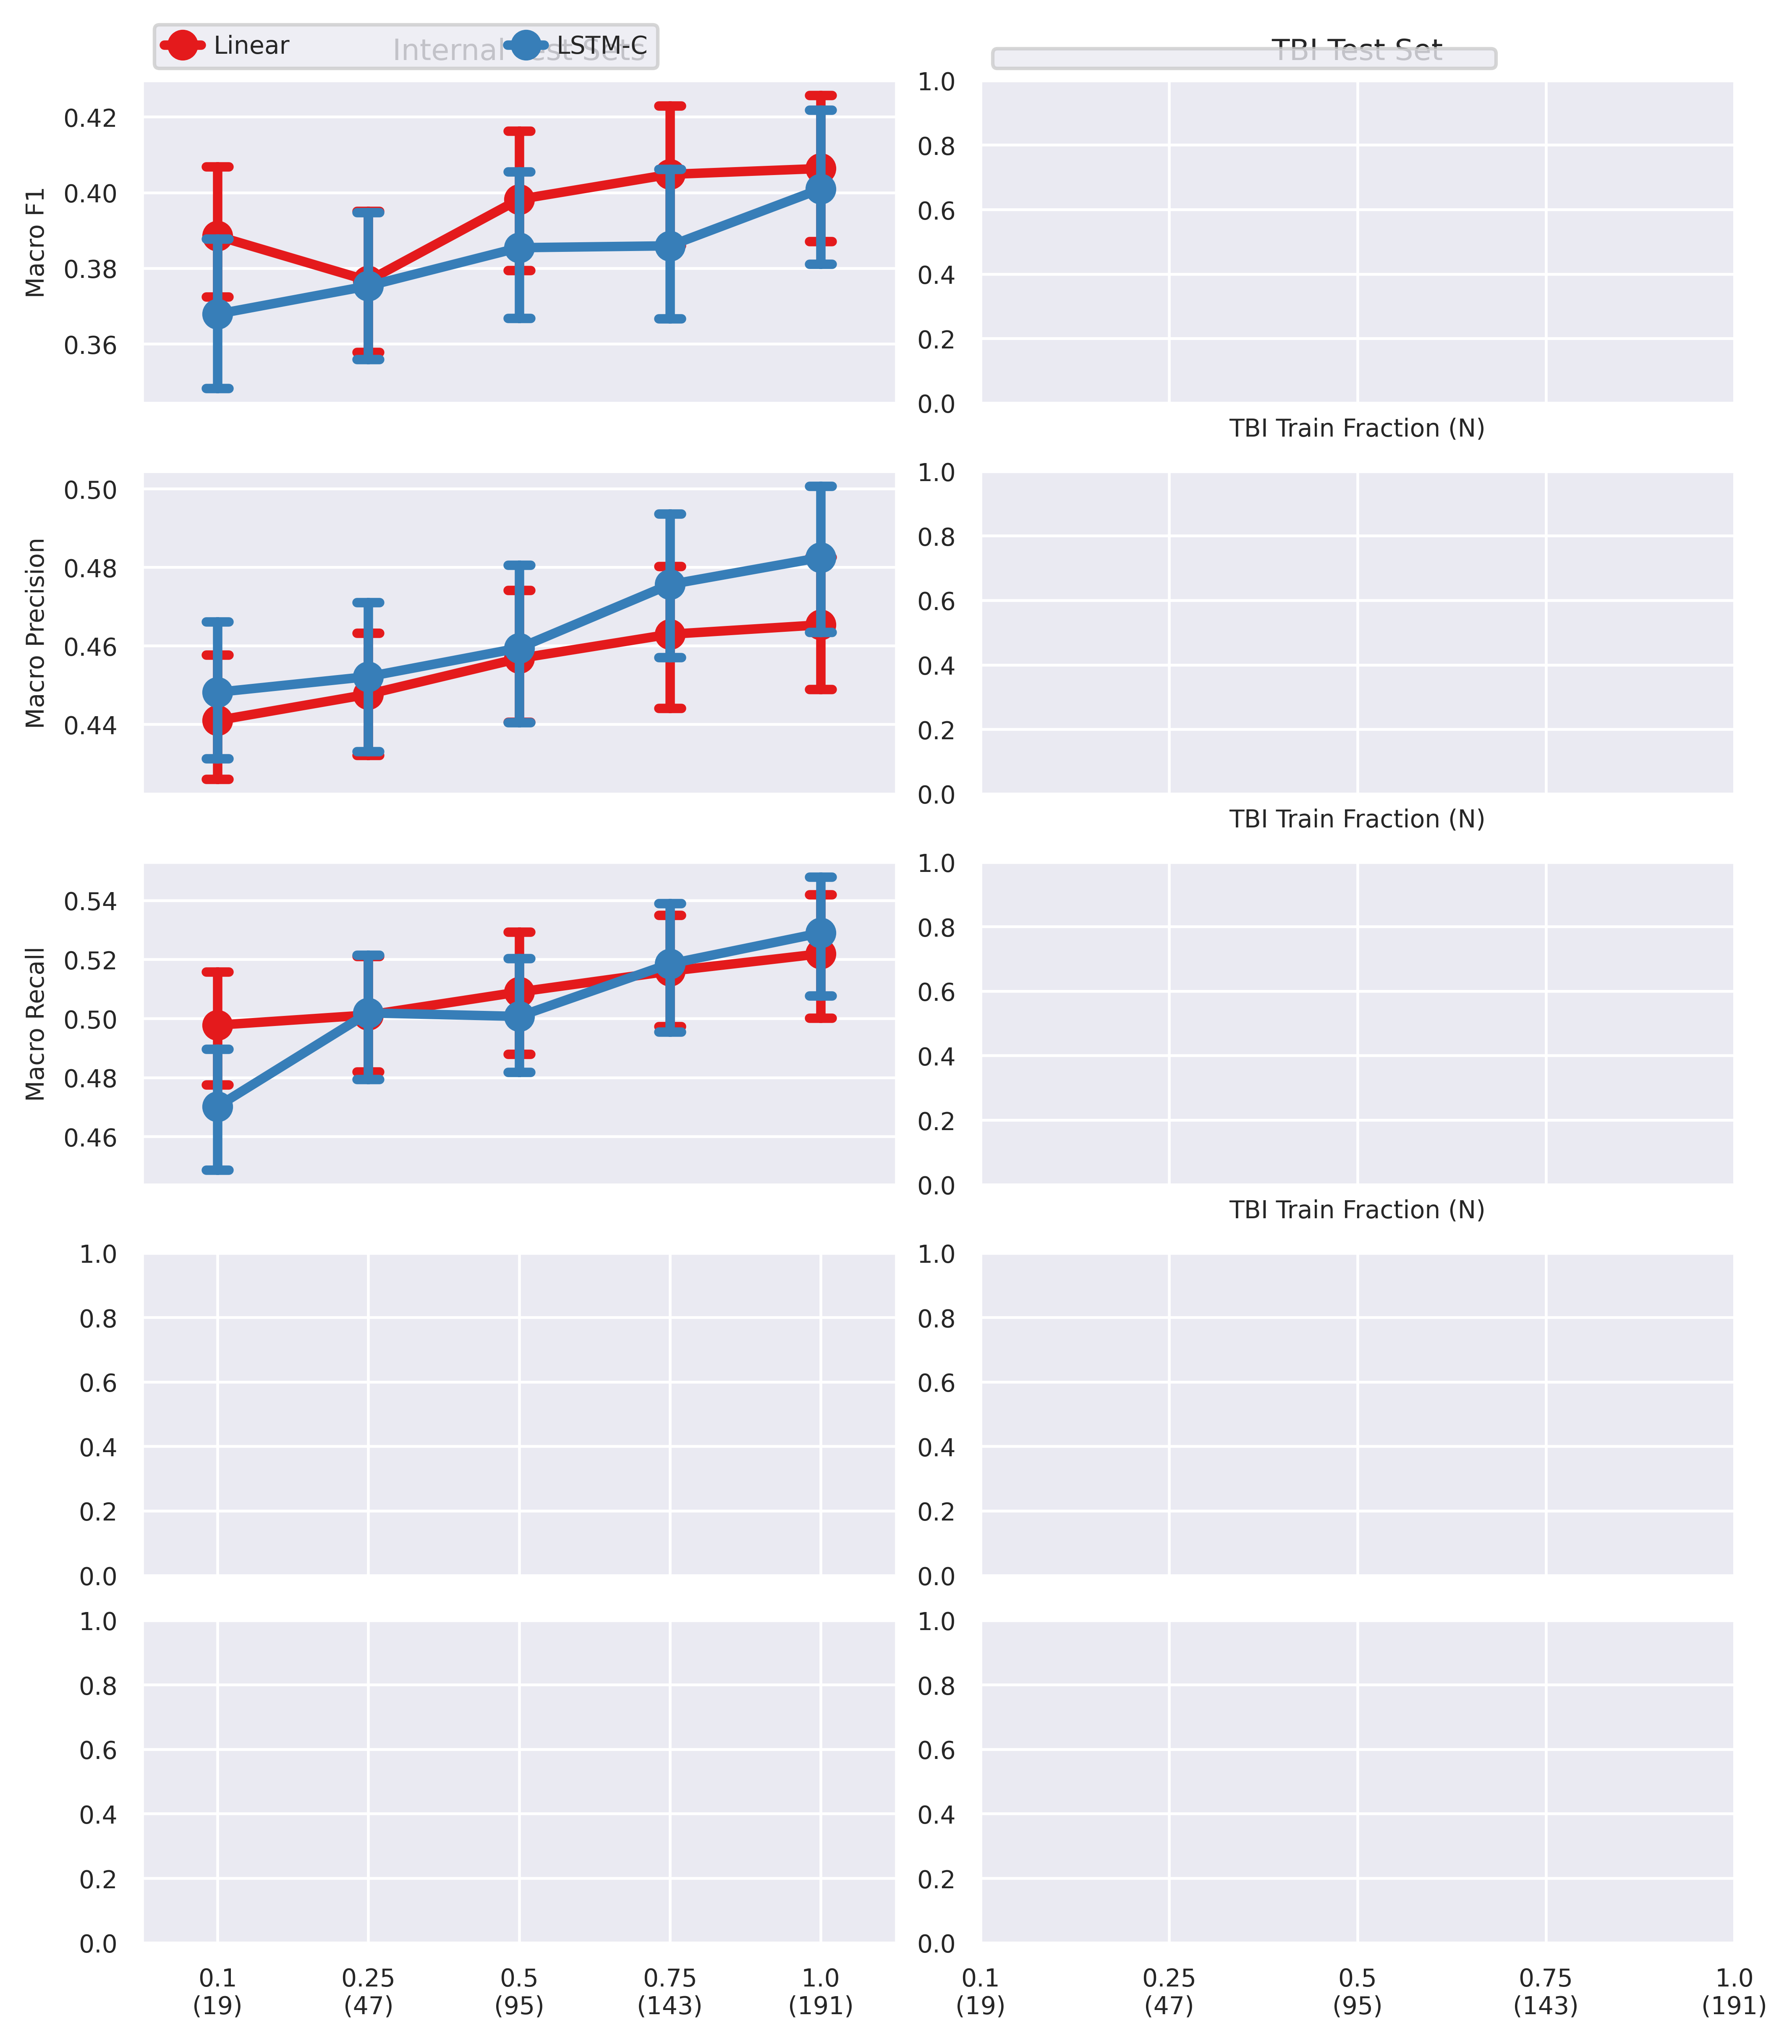

In [29]:
sns.set_style('darkgrid')
metrics = ['F1', 'Precision', 'Recall','AUC', 'Kappa']
nsubs = [19, 47, 95, 143, 191]

fig, axes = plt.subplots(len(metrics),2, dpi=600, figsize=(7,8),layout='constrained',sharex='col')

macro_no_tbi = macro_results[macro_results['dataset'] != 'TBI']
macro_tbi = macro_results[macro_results['dataset'] == 'TBI']

for i, metric in enumerate(metrics):
    ax0 = sns.pointplot(
        macro_no_tbi, x='tp', y=metric, hue='classifier', ax=axes[i,0], 
        capsize=0.15, palette='Set1', legend=i==0
    )
    ax1 = sns.pointplot(
        macro_tbi, x='tp', y=metric, hue='classifier', ax=axes[i,1], 
        capsize=0.15, palette='Set1', legend=i==0
    )
    # ax1 = sns.boxplot(
    #     macro_no_tbi, x='tp', y=metric, hue='classifier', saturation=0.75, ax=axes[i,1],
    #     showfliers=False, palette='Set1'
    # )
    ax0.set_ylabel(f'Macro {metric}')
    ax1.set_ylabel('')
    ax0.set_xticks([0, 1, 2, 3, 4], ['0.1\n(19)', '0.25\n(47)', '0.5\n(95)', '0.75\n(143)', '1.0\n(191)'])
    ax0.set_xlabel('TBI Train Fraction (N)')

    ax1.set_xticks([0, 1, 2, 3, 4], ['0.1\n(19)', '0.25\n(47)', '0.5\n(95)', '0.75\n(143)', '1.0\n(191)'])
    ax1.set_xlabel('TBI Train Fraction (N)')
    if i == 0:
        ax0.set_title('Internal Test Sets')
        ax1.set_title('TBI Test Set')
        ax0.legend(bbox_to_anchor = (0,1,0.7,1), loc='lower left', ncols=2, 
            mode='expand', handletextpad=0.5, handlelength=1.5)
        ax1.legend(bbox_to_anchor = (0,1,0.7,1), loc='lower left', ncols=2, 
            mode='expand', handletextpad=0.5, handlelength=1.5)

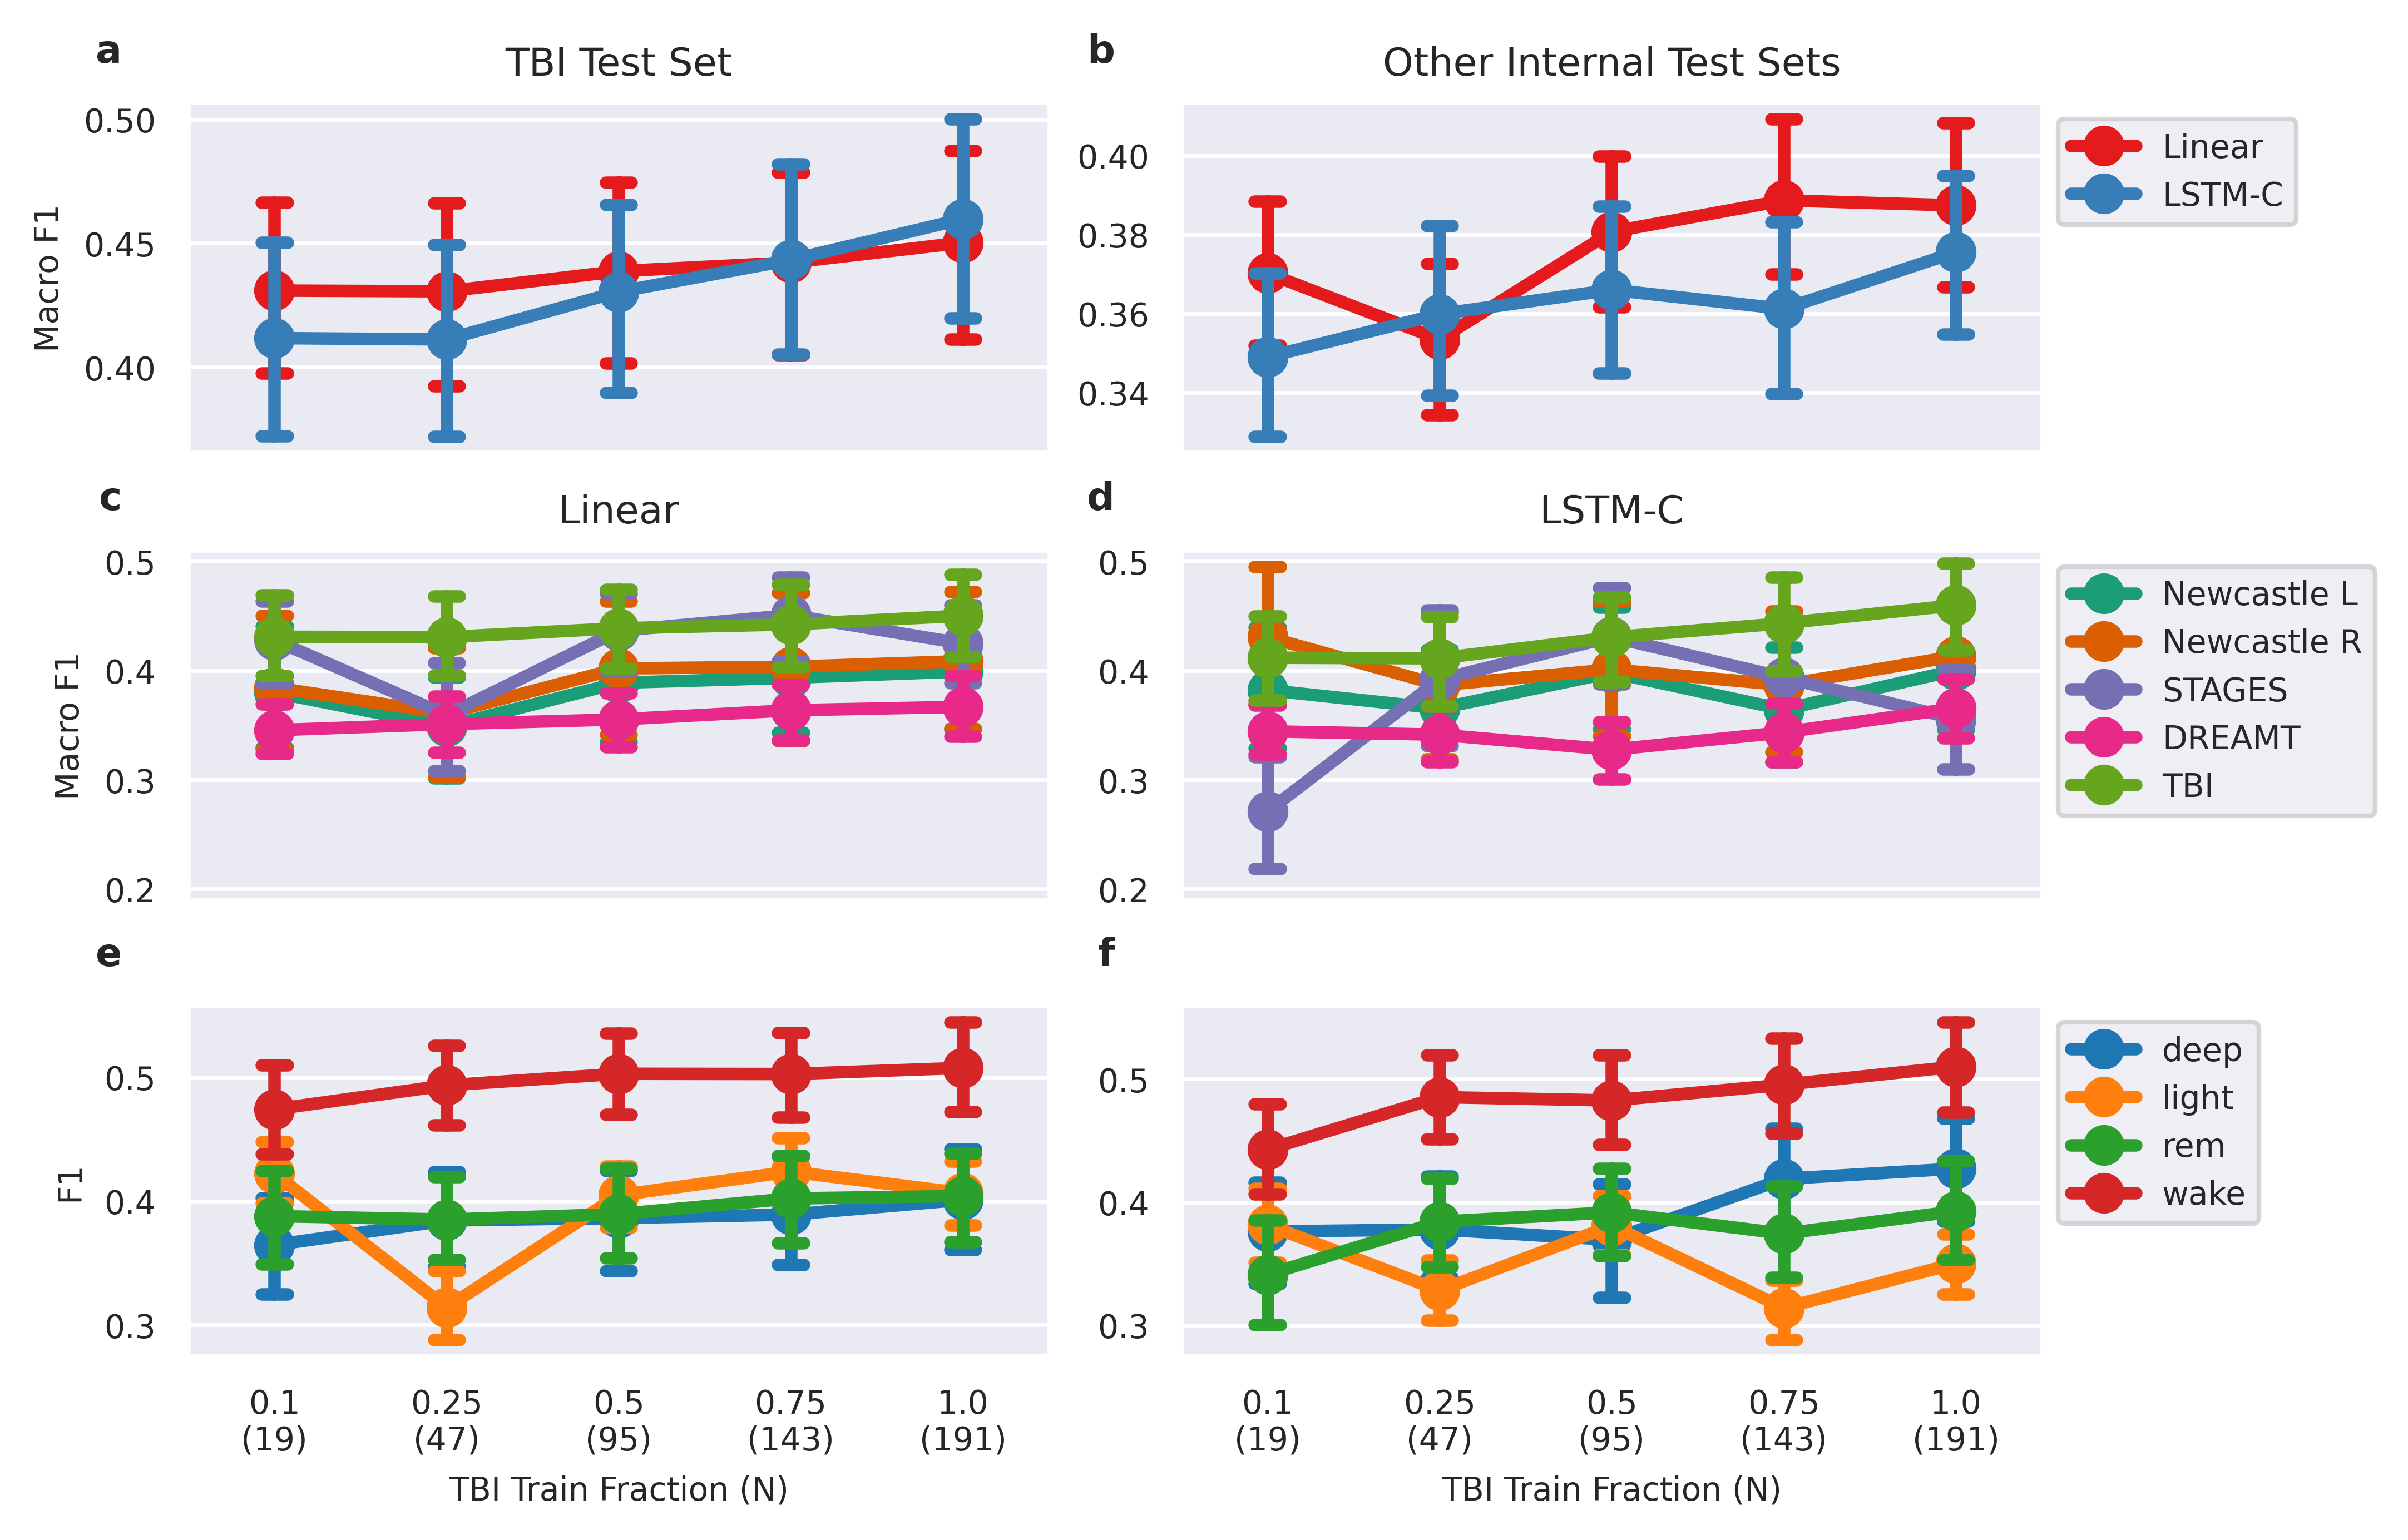

In [40]:
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 7
matplotlib.rcParams['font.family'] = 'sans-serif'

metric = 'F1'#, 'Precision', 'Recall','AUC', 'Kappa']
cw_df = cw_f1s
nsubs = [19, 47, 95, 143, 191]

fig, axes = plt.subplots(3, 2, dpi=600, figsize=(7.1,4.5),layout='constrained',sharex='col')
# macro_no_stages = macro_results[macro_results['dataset'] != 'STAGES']
macro_no_tbi = macro_results[macro_results['dataset'] != 'TBI']
macro_tbi = macro_results[macro_results['dataset'] == 'TBI']

ax_tbi = sns.pointplot(
    macro_tbi, x='tp', y=metric, hue='classifier', ax=axes[0,0], 
    capsize=0.15, palette='Set1', legend=False
)
ax_no_tbi = sns.pointplot(
    macro_no_tbi, x='tp', y=metric, hue='classifier', ax=axes[0,1], 
    capsize=0.15, palette='Set1', legend=True
)
ax_no_tbi.legend(bbox_to_anchor = (1,1), loc='upper left')

ax_tbi.set_ylabel(f'Macro {metric}')
ax_tbi.set_title('TBI Test Set')
ax_no_tbi.set_ylabel('')
ax_no_tbi.set_title('Other Internal Test Sets')

# # if i == 0:
#     ax0.legend(bbox_to_anchor = (0,1,0.7,1), loc='lower left', ncols=2, 
#         mode='expand', handletextpad=0.5, handlelength=1.5)

classifiers = [macro_results_lin, macro_results_lstmc]

ax_lin = sns.pointplot(
    macro_results_lin, x='tp', y=metric, hue='dataset', ax=axes[1,0],
    capsize=0.15, palette='Dark2', legend=False,
    hue_order=['Newcastle L', 'Newcastle R', 'STAGES', 'DREAMT', 'TBI']
)

ax_lstmc = sns.pointplot(
    macro_results_lstmc, x='tp', y=metric, hue='dataset', ax=axes[1,1],
    capsize=0.15, palette='Dark2', legend=True,
    hue_order=['Newcastle L', 'Newcastle R', 'STAGES', 'DREAMT', 'TBI']
)
if metric == 'F1':
    ax_lin.set_yticks(np.arange(0.2, 0.51, 0.1))
    ax_lin.set_ylim(0.19,0.51)
    ax_lstmc.set_yticks(np.arange(0.2, 0.51, 0.1))
    ax_lstmc.set_ylim(0.19,0.51)

ax_lin.set_title('Linear')
ax_lin.set_ylabel(f'Macro {metric}')

ax_lstmc.set_title('LSTM-C')
ax_lstmc.set_ylabel('')

ax_lstmc.legend(bbox_to_anchor = (1,1), loc='upper left')


cw_df['dataset'] = dataset_i
cw_df['classifier'] = exp_i
cw_df['tp'] = tp_i

cw_df = cw_df.melt(id_vars=['dataset', 'classifier', 'tp'])

ax_lin_cw = sns.pointplot(
    cw_df[cw_df['classifier'] == 'Linear'], x='tp', y='value', hue='variable', ax=axes[2,0],
    capsize=0.15, palette='tab10', legend=False,
    # hue_order=['Newcastle L', 'Newcastle R', 'STAGES', 'DREAMT', 'TBI']
)
ax_lin_cw.set_ylabel(metric)

ax_lstmc_cw = sns.pointplot(
    cw_df[cw_df['classifier'] == 'LSTM-C'], x='tp', y='value', hue='variable', ax=axes[2,1],
    capsize=0.15, palette='tab10', legend=True,
    # hue_order=['Newcastle L', 'Newcastle R', 'STAGES', 'DREAMT', 'TBI']
)
ax_lstmc_cw.legend(bbox_to_anchor = (1,1), loc='upper left')
ax_lstmc_cw.set_ylabel('')

for ax in axes[-1]:
    ax.set_xticks([0, 1, 2, 3, 4], ['0.1\n(19)', '0.25\n(47)', '0.5\n(95)', '0.75\n(143)', '1.0\n(191)'])
    ax.set_xlabel('TBI Train Fraction (N)')

for i, ax in enumerate(axes.ravel()):
    # Add alphabetic ordering
    ax.annotate(
        f'{chr(97+i)}',
        xy=(-0.1, 1.15), xycoords='axes fraction',
        xytext=(+0.5, -0.5), textcoords='offset fontsize',  fontweight='bold',
        fontsize='large', verticalalignment='bottom', horizontalalignment='right',# fontfamily='verdana',
        bbox=dict(facecolor='none', edgecolor='none', pad=3.0)
    )

In [90]:
import itertools
from scipy.stats import ttest_rel

# macro_results.drop(columns=['subject']).groupby(['tp', 'dataset', 'classifier']).mean()

output = []
df = macro_no_tbi.melt(id_vars=['tp', 'dataset', 'classifier', 'subject']).rename(columns={'variable':'metric'})
for (tp, metric), g in df.groupby(['tp', 'metric']):
    # Pivot so rows=folds, cols=models
    wide = g.pivot(index="subject", columns="classifier", values="value")

    # Iterate over all pairs of models
    for m1, m2 in itertools.combinations(wide.columns, 2):
        vals1 = wide[m1].dropna()
        vals2 = wide[m2].dropna()

        # Align folds (important if some are missing)
        aligned = pd.concat([vals1, vals2], axis=1, join="inner").dropna()
        if aligned.shape[0] > 1:  # need at least 2 folds
            stat, pval = ttest_rel(aligned[m1], aligned[m2])
            output.append({
                "tp": tp,
                "metric": metric,
                "model1": m1,
                "model2": m2,
                "t_stat": stat,
                "p_value": pval
            })

output_df = pd.DataFrame(output)
output_df = output_df.rename(
    columns={'tp': 'TBI Train Fraction'}
).pivot(index='metric', columns='TBI Train Fraction',values='p_value')
# mean_df = df.drop(columns=['subject']).groupby(['tp', 'dataset', 'classifier']).mean()
# sd_df = df.drop(columns=['subject']).groupby(['tp', 'dataset', 'classifier']).std()
# new_df = mean_df.round(3).astype(str) + " ± " + sd_df.round(3).astype(str)
mean_df = df.drop(
    columns=['subject', 'dataset']
).groupby(
    ['tp', 'classifier','metric']
).mean().reset_index('tp').rename(
    columns={'tp': 'TBI Train Fraction'}
).pivot(columns='TBI Train Fraction', values='value')

sd_df = df.drop(
    columns=['subject', 'dataset']
).groupby(
    ['tp', 'classifier','metric']
).std().reset_index('tp').rename(
    columns={'tp': 'TBI Train Fraction'}
).pivot(columns='TBI Train Fraction', values='value')
mean_sd_df = mean_df.round(3).astype(str) + " ± " + sd_df.round(3).astype(str)
mean_sd_df = mean_sd_df.swaplevel('metric', 'classifier').sort_values(['metric','classifier'])



In [91]:
output_df

TBI Train Fraction,0.10,0.25,0.50,0.75,1.00
metric,,,,,
AUROC,0.024543,0.784335,0.280881,0.019599,0.009347
F1,0.024901,0.315670,0.032290,0.000044,0.058295
Kappa,0.065824,0.036808,0.036920,0.007641,0.579911
Precision,0.406440,0.096899,0.856327,0.113053,0.015441
Recall,0.012379,0.508909,0.125636,0.734011,0.537381


In [92]:
mean_sd_df

TBI Train Fraction             0.10           0.25           0.50  \
metric    classifier                                                
AUROC     LSTM-C      0.716 ± 0.096  0.738 ± 0.101  0.743 ± 0.111   
          Linear      0.731 ± 0.095   0.74 ± 0.098  0.749 ± 0.103   
F1        LSTM-C      0.349 ± 0.113   0.36 ± 0.115  0.366 ± 0.115   
          Linear       0.37 ± 0.102  0.353 ± 0.104  0.381 ± 0.106   
Kappa     LSTM-C        0.2 ± 0.125   0.222 ± 0.13  0.215 ± 0.136   
          Linear      0.221 ± 0.126  0.207 ± 0.123  0.234 ± 0.132   
Precision LSTM-C      0.428 ± 0.099  0.438 ± 0.101  0.435 ± 0.117   
          Linear       0.421 ± 0.09  0.428 ± 0.092  0.434 ± 0.101   
Recall    LSTM-C      0.461 ± 0.127  0.496 ± 0.135  0.489 ± 0.134   
          Linear      0.486 ± 0.116   0.49 ± 0.123  0.501 ± 0.127   

TBI Train Fraction             0.75           1.00  
metric    classifier                                
AUROC     LSTM-C      0.764 ± 0.108  0.769 ± 0.103  
          Linear      0.754 ± 0.104  0.757 ± 0.103  
F1        LSTM-C      0.361 ± 0.116   0.376 ± 0.11  
          Linear      0.389 ± 0.109  0.387 ± 0.108  
Kappa     LSTM-C      0.224 ± 0.131   0.24 ± 0.126  
          Linear      0.244 ± 0.133  0.244 ± 0.131  
Precision LSTM-C      0.455 ± 0.113  0.465 ± 0.119  
          Linear      0.442 ± 0.103  0.445 ± 0.101  
Recall    LSTM-C      0.512 ± 0.135   0.52 ± 0.132  
          Linear      0.509 ± 0.128  0.515 ± 0.131

In [33]:
var_df = macro_results.drop(columns=['subject']).groupby(['tp', 'dataset', 'classifier']).var()
mean_df = macro_results.drop(columns=['subject']).groupby(['tp', 'dataset', 'classifier']).mean()
# new_df = mean_df.round(3).astype(str) + " ± " + sd_df.round(3).astype(str)
# # new_df.to_csv('/oak/stanford/groups/mignot/projects/actigraphy_fm/results/tp_macro_results.csv')
# new_df
mean_df.groupby(['dataset', 'classifier']).mean()
var_df.groupby(['tp', 'classifier']).mean()

Precision    Recall        F1     Kappa       AUC
tp   classifier                                                   
0.10 LSTM-C       0.012022  0.016415  0.014561  0.017730  0.010678
     Linear       0.009720  0.013374  0.012139  0.016309  0.008642
0.25 LSTM-C       0.012013  0.018088  0.015903  0.019626  0.010458
     Linear       0.010167  0.014055  0.012995  0.016166  0.009954
0.50 LSTM-C       0.014523  0.016710  0.013648  0.020761  0.010966
     Linear       0.011945  0.014683  0.012515  0.018020  0.010025
0.75 LSTM-C       0.016114  0.018156  0.016078  0.021425  0.011589
     Linear       0.012603  0.014728  0.013366  0.018442  0.010297
1.00 LSTM-C       0.015269  0.016320  0.013532  0.018307  0.010445
     Linear       0.011944  0.015262  0.013067  0.018283  0.010254